# `gc` Garbage Collector Module

The `gc` module is Python’s built-in interface to its optional **generational garbage collector**, which is primarily used to detect and clear **cyclic references (circular loops)** that reference counting alone cannot destroy. While Python automatically reclaims memory the exact moment an object's reference count drops to zero, self-referencing loops (e.g., Object A points to Object B, and Object B points to Object A) never hit a zero reference count. The `gc` module allows you to track, tweak, and trigger this background cyclic cleanup process manually.

# Python's Generational Strategy

A **generational garbage collector** is a memory management system based on the empirical rule that **most objects die young**. Instead of scanning every single object in memory during every cleanup cycle—which is slow—the system groups objects into different "generations" based on how long they have been alive.

### 1. Python's Generational Strategy

- **Generation 0 (Young)**: Contains all newly allocated objects. It is scanned frequently.

- **Generation 1 (Middle-aged)**: Houses intermediate objects that survived a Generation 0 sweep.

- **Generation 2 (Old)**: Holds long-lived objects that survived multiple past garbage collection cycles. It is scanned rarely due to the higher processing costs involved.


### 2. Why It Is Efficient

- **Saves Time**: Long-lived objects (like global variables or imported modules in Generation 2) are rarely checked.

- **Focuses Effort**: The collector spends most of its energy scanning Generation 0, where it can quickly find and destroy short-lived, temporary objects.

<br>

---

<br>

# Core Functions & Methods

- **`gc.collect(generation=None)`**: Manually triggers a full or generation-specific garbage collection sweep and returns the total number of unreachable objects destroyed.

- **`gc.disable()`**: Completely turns off automatic garbage collection. This is occasionally used to maximize execution speed during short, performance-critical code blocks. 

- **`gc.enable()`**: Re-enables the automatic background garbage collector after it has been disabled.

- **`gc.isenabled()`**: Returns a boolean indicating if automatic collection is currently active.

- **`gc.get_threshold()`**: Returns a tuple (threshold0, threshold1, threshold2) containing the frequency collection settings across Python's three memory generations.

- **`gc.set_threshold(threshold0[, threshold1[, threshold2]])`**: Adjusts the frequency thresholds for triggering automatic collection sweeps.

<br>

---

<br>

# Example 1: Finding and Clearing Circular References

Normal reference counting cannot delete objects that point to each other. The gc module can.

In [18]:
import gc

class Node:
    def __init__(self, name):
        self.name = name
        self.link = None


# 1. Create a circular reference loop
a = Node("A")
b = Node("B")

a.link = b      # A points B
b.link = a      # B points A

### 1. Diagram

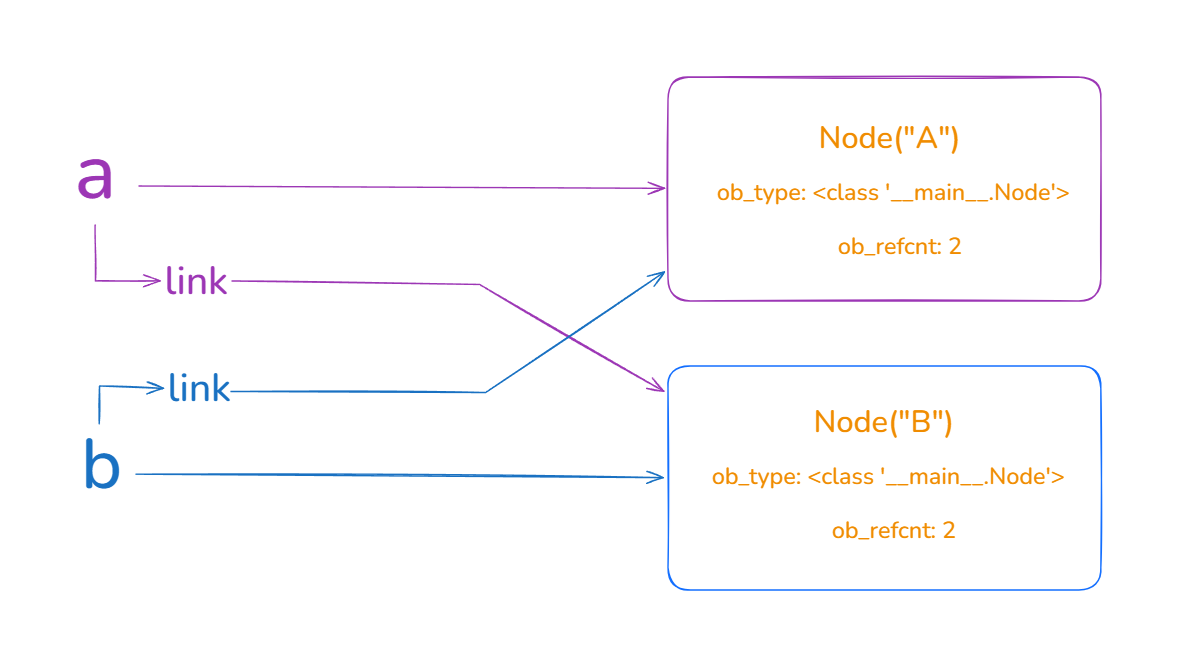
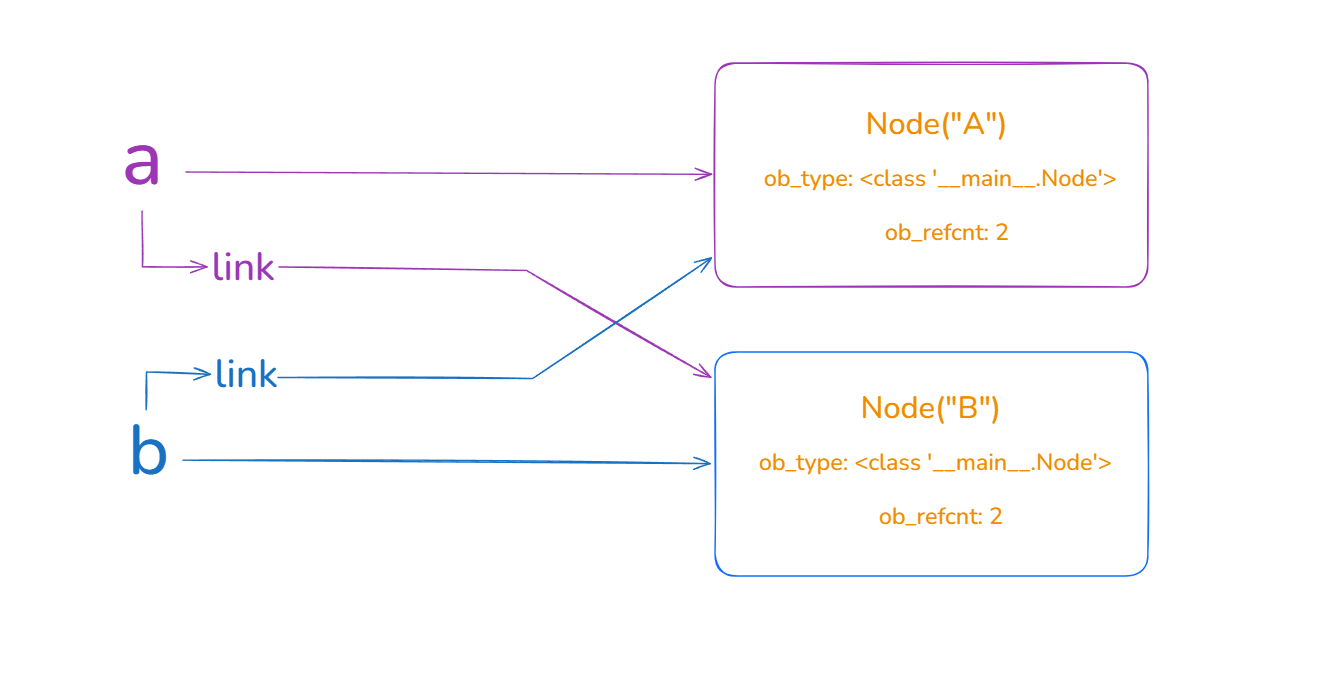

In [ ]:
# 2. Save address before destroying the labels
address_of_A = id(a)
address_of_B = id(b)

# 3. Break the access hooks, leaving them trapped in memory
a = None
b = None

### 2. The Deletion Phase

- `a = None`

    * You destroyed the global arrow `a`.
    * Node A's refcnt drops by 1.
    * Node A refcnt: 1 (Because `b.link` is still pointing at it!)

- `b = None`

    * You destroyed the global arrow `b`.
    * Node B's refcnt drops by 1.
    * Node B refcnt: 1 (Because `a.link` is still pointing at it!)

In [21]:
import ctypes

a_refcnt = ctypes.c_long.from_address(address_of_A).value
b_refcnt = ctypes.c_long.from_address(address_of_B).value

# refcnt using address before destroying of labels 
print(f"a_refcnt: {a_refcnt}")
print(f"b_refcnt: {b_refcnt}")

a_refcnt: 1
b_refcnt: 1


**The Result**: Both objects have a reference count of 1. Because standard reference counting only destroys objects when the count hits 0, Python leaves them in memory. They have formed an isolated island. They are holding hands, keeping each other alive, but you have thrown away the bridge to reach them.

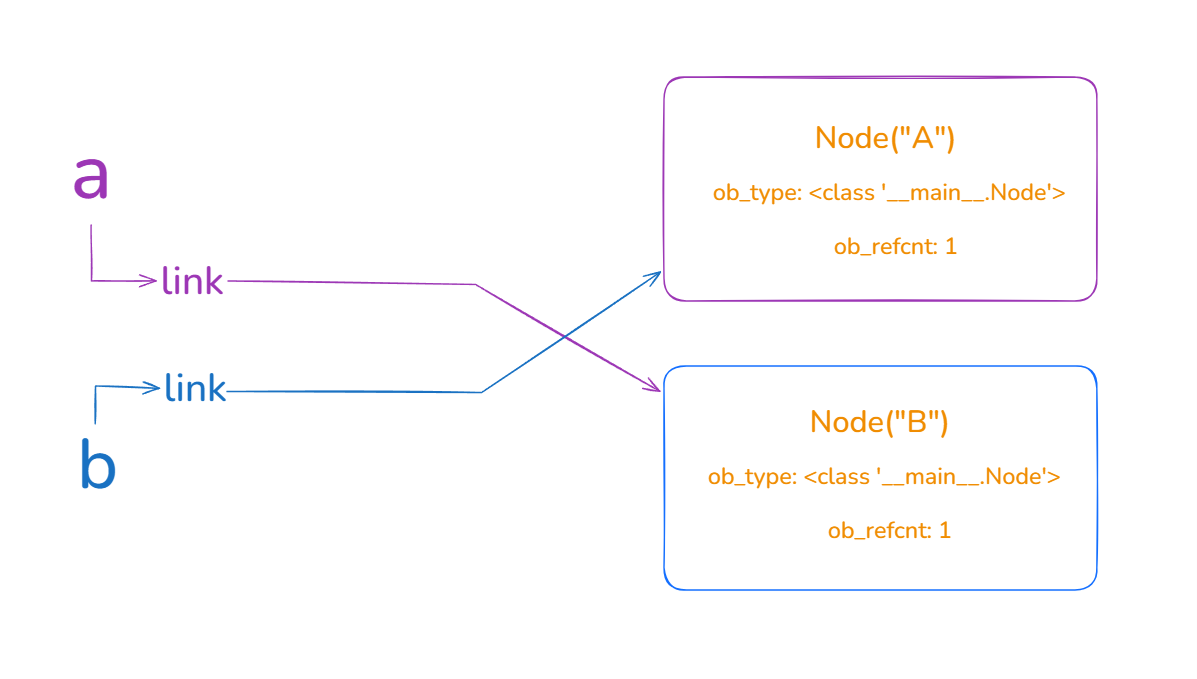

In [22]:
# 3. Force the GC to find and destroy the cyclic loop
unreachable_count = gc.collect()
print(f"Destroyed {unreachable_count} circular reference objects.")

Destroyed 2909 circular reference objects.


In [26]:
a_refcnt = ctypes.c_long.from_address(address_of_A).value
b_refcnt = ctypes.c_long.from_address(address_of_B).value

# refcnt using address before destroying of labels 
print(f"a_refcnt: {a_refcnt}")
print(f"b_refcnt: {b_refcnt}")

a_refcnt: 0
b_refcnt: 0


<br>

---

<br>

# Example 2: Inspecting Object Dependencies (Debugging Leaks)

If your code is leaking memory, use `gc.get_referrers()` to find out what hidden variable or container is holding onto an object and keeping it alive.

In [3]:
import gc

secret_cache = []

my_data = {"status": "active"}

# Something secretly saves our data
secret_cache.append(my_data)

# Find out what is pointing to my_data
owners = gc.get_referrers(my_data)          # owners(referrers): all labels arrows pointing at my_data

for owner in owners:
    print(type(owner))

print("\n")

for owner in owners:
    if isinstance(owner, list):
        print("Yes it is listing secretly holding arrow on my_data")

<class 'dict'>
<class 'list'>


Yes it is listing secretly holding arrow on my_data


<br>

---

<br>

# Example 3: Disabling GC for High-Speed Code Blocks

If you are running a tight loop that creates millions of temporary objects, Python might freeze mid-loop to run garbage collection. Disabling it temporarily makes the code faster and more predictable.

In [4]:
import gc

# 1. disable background collection for performance
gc.disable()

try:
    # 2. Run a high-speed, intensive operation
    results = [x * 2 for x in range(10_000_000)]
    
finally:
    # 3. Always re-enable it afterward to prevent long-term leaks
    gc.enable()
    gc.collect()        # Clean up the leftovers manually

<br>

---

<br>

# Example 4: Tracking Memory Health with `gc.get_stats()`

This script prints your memory health before and after a deliberate cycle is created and cleared:

In [5]:
import gc

def print_gc_health():
    stats = gc.get_stats()
    # Let's inspect Generation 0 (index 0) where new objects land
    gen0 = stats[0]
    print(f"Gen 0 -> Sweeps: {gen0['collections']}, Cleared Objects: {gen0['collected']}")

print("--- Initial stats ---")
print_gc_health()

# Create 50,000 circular loops to bloat Generation 0
for _ in range(50_000):
    lst1 = []
    lst2 = []
    lst1.append(lst2)
    lst2.append(lst1)

# Force a manual sweep to clean up our mess
gc.collect()

print("\n--- After Creating & Cleaning Loops ---")
print_gc_health()

--- Initial stats ---
Gen 0 -> Sweeps: 0, Cleared Objects: 0

--- After Creating & Cleaning Loops ---
Gen 0 -> Sweeps: 0, Cleared Objects: 0


<br>

---

<br>

# Example 5: Preventing Loops Entirely with `weakref`

Instead of letting circular references happen and relying on the GC to fix them later, you can use the `weakref` module.

A normal reference (strong reference) increments an object’s reference count, keeping it alive. A weak reference points to an object without increasing its reference count. If all strong references vanish, Python deletes the object instantly, preventing the cycle from ever forming.

> Think of a Parent node that owns a Child node, but the Child needs to know who its parent is.

In [6]:
import gc
import weakref

class Parent:
    def __init__(self):
        # Strong reference: Parent owns Child
        self.child = Child(self) 

class Child:
    def __init__(self, parent_obj):
        # WEAK reference: Points to parent without "owning" it
        self.parent = weakref.ref(parent_obj)

# 1. Create the relationship
mom = Parent()

# 2. To talk to the parent from the child, you call it like a function:
parent_reference = mom.child.parent()
print(f"Child's parent exists: {parent_reference is not None}") # True

# 3. Delete the parent strong reference
mom = None 

# 4. Because we used weakref, it drops to 0 count and deletes instantly.
# Let's run a manual check to prove the GC didn't have to clean up a loop:
unreachable = gc.collect()
print(f"GC had to destroy {unreachable} cyclic loops.") # Output will be 0!

Child's parent exists: True
GC had to destroy 0 cyclic loops.
